In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_parquet(
    path=r"./datasets/clean_data.parquet",
    engine="pyarrow",
)
data.head()

,userId,movieId,rating,title,genres,TotalRatingCount
0,1,2,3.5,Jumanji (1995),Adventure|Children|Fantasy,22243
1,1,29,3.5,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,8520
2,1,32,3.5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,44980
3,1,47,3.5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,43249
4,1,50,3.5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,47006


<Axes: xlabel='TotalRatingCount'>

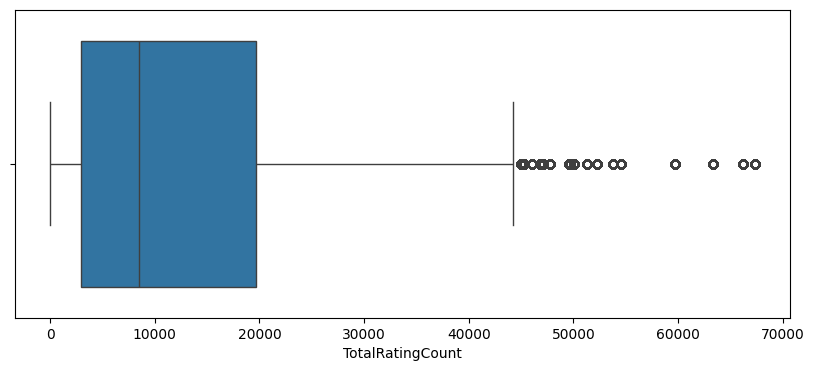

In [5]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=data, x="TotalRatingCount")

In [6]:
data["TotalRatingCount"].quantile(0.1)

np.float64(879.0)

In [7]:
for i in range(0, 100, 10):
    print(f"{i}th percentile value is {data['TotalRatingCount'].quantile(i/100)}")

0th percentile value is 1.0
10th percentile value is 879.0
20th percentile value is 2141.0
30th percentile value is 3876.0
40th percentile value is 5933.0
50th percentile value is 8505.0
60th percentile value is 11986.0
70th percentile value is 15909.0
80th percentile value is 23309.0
90th percentile value is 33024.0


In [8]:
# Q1 = data["TotalRatingCount"].quantile(0.25)  # 25th percentile
# Q3 = data["TotalRatingCount"].quantile(0.75)  # 75th percentile
# IQR = Q3 - Q1
# threshold = Q3 + 1.5 * IQR  # Upper bound for outliers

# print(f"The calculated threshold is: {threshold}")

# filtered_data = data[data["TotalRatingCount"] > threshold]

In [9]:
threshold = data["TotalRatingCount"].quantile(0.80)  # Top 20% most-rated movies

In [10]:
rating_popular_movie = data.query(f"TotalRatingCount > {threshold}")

In [11]:
rating_popular_movie.columns

Index(['userId', 'movieId', 'rating', 'title', 'genres', 'TotalRatingCount'], dtype='object')

In [12]:
rating_popular_movie.shape

(3980490, 6)

In [13]:
rating_popular_movie.head()

,userId,movieId,rating,title,genres,TotalRatingCount
2,1,32,3.5,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,44980
3,1,47,3.5,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,43249
4,1,50,3.5,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,47006
7,1,223,4.0,Clerks (1994),Comedy,23695
8,1,253,4.0,Interview with the Vampire: The Vampire Chroni...,Drama|Horror,27568


In [14]:
movieMath = rating_popular_movie.pivot_table(
    index="userId", columns="title", values="rating"
)

In [15]:
movieMath.head()

title,2001: A Space Odyssey (1968),Ace Ventura: Pet Detective (1994),Aladdin (1992),Alien (1979),Aliens (1986),"Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",American Beauty (1999),Apollo 13 (1995),Austin Powers: The Spy Who Shagged Me (1999),Babe (1995),...,Trainspotting (1996),True Lies (1994),"Truman Show, The (1998)",Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Twister (1996),"Usual Suspects, The (1995)",Waterworld (1995),Willy Wonka & the Chocolate Factory (1971),"Wizard of Oz, The (1939)",X-Men (2000)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.5,NaN,NaN,4.0,4.0,NaN,NaN,NaN,3.5,NaN,...,NaN,NaN,NaN,3.5,NaN,3.5,NaN,NaN,3.5,NaN
2,5.0,NaN,NaN,5.0,NaN,NaN,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.0,NaN,NaN,5.0,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,5.0,NaN,5.0,4.0,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,NaN,5.0,NaN,NaN,5.0,NaN,NaN,2.0,NaN,NaN


In [22]:
# similarity = movieMath.corrwith(movieMath["Pulp Fiction (1994)"])
# sorted_similarity = similarity.sort_values(ascending=False)[1:]
# correlation = sorted_similarity.reset_index().rename(columns={0: "correlation"})
# correlation.head()

In [23]:
# Compute movie-to-movie similarity
movie_corr = movieMath.corr()

In [27]:
# Find top movies similar to "Movie A"
movie_corr["Pulp Fiction (1994)"].sort_values(ascending=False)[1:]

title
Reservoir Dogs (1992)          0.510497
Natural Born Killers (1994)    0.355001
Trainspotting (1996)           0.348773
Goodfellas (1990)              0.343675
Fight Club (1999)              0.328060
                                 ...   
Sleepless in Seattle (1993)   -0.081983
Twister (1996)                -0.086830
Mrs. Doubtfire (1993)         -0.087166
Ghost (1990)                  -0.096799
Net, The (1995)               -0.152156
Name: Pulp Fiction (1994), Length: 116, dtype: float64